# Семинар 6 - Классические алгоритмы сегментации изображения и обнаружения объектов

**Данный семинар содержит ДЗ**

***

In [64]:
import random as rng

import cv2
import numpy as np
import matplotlib.pyplot as plt

rng.seed(12345)

In [65]:
# !mkdir -p data
# !wget https://github.com/opencv/opencv/raw/4.x/samples/data/cards.png -O data/cards.png

# Image Segmentation with Distance Transform and Watershed Algorithm

Источник - https://docs.opencv.org/3.4/d2/dbd/tutorial_distance_transform.html

В этом семинаре вы узнаете, как:

- Использовать `cv2.filter2D`, чтобы выполнить фильтрацию Лапласа для повышения резкости изображения.
- Использовать `cv2.distanceTransform`, чтобы получить производное представление двоичного изображения, где значение каждого пикселя заменяется его расстоянием до ближайшего пикселя фона.
- Использовать `cv2.watershed`, чтобы изолировать объекты на изображении от фона.

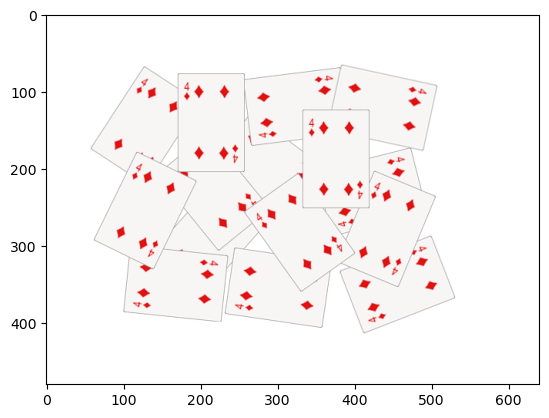

In [66]:
img_src = cv2.cvtColor(cv2.imread("data/cards.png"), cv2.COLOR_BGR2RGB)
plt.imshow(img_src);

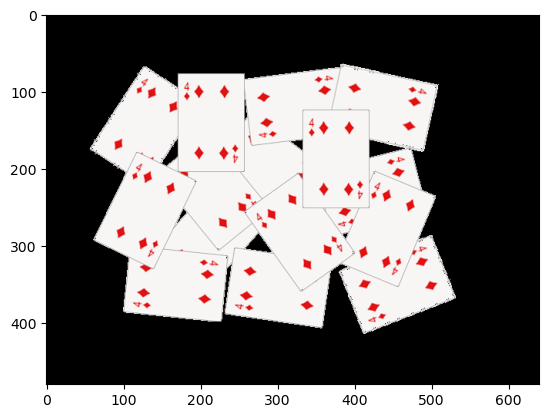

In [67]:
# Change the background from white to black, since that will help later to extract
# better results during the use of Distance Transform
img = img_src.copy()
img[np.all(img == 255, axis=2)] = 0

plt.imshow(img);

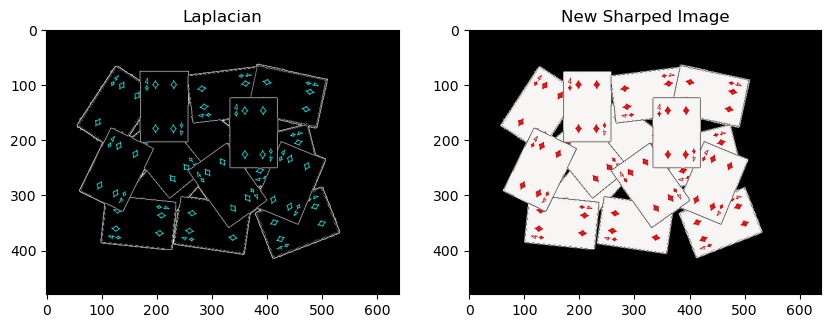

In [68]:
# Create a kernel that we will use to sharpen our image
# an approximation of second derivative, a quite strong kernel
kernel = np.array(
    [[  1,  1,  1],
     [  1, -8,  1],
     [  1,  1,  1]], dtype=np.float32)
# do the laplacian filtering as it is
# well, we need to convert everything in something more deeper then CV_8U
# because the kernel has some negative values,
# and we can expect in general to have a Laplacian image with negative values
# BUT a 8bits unsigned int (the one we are working with) can contain values from 0 to 255
# so the possible negative number will be truncated
imgLaplacian = cv2.filter2D(img, cv2.CV_32F, kernel)
sharp = np.float32(img)
imgResult = sharp - imgLaplacian

# convert back to 8bits gray scale
imgResult = np.clip(imgResult, 0, 255)
imgResult = imgResult.astype('uint8')
imgLaplacian = np.clip(imgLaplacian, 0, 255)
imgLaplacian = np.uint8(imgLaplacian)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(imgLaplacian)
plt.title('Laplacian')
plt.subplot(122)
plt.imshow(imgResult)
plt.title('New Sharped Image');

### Бинаризация изображения

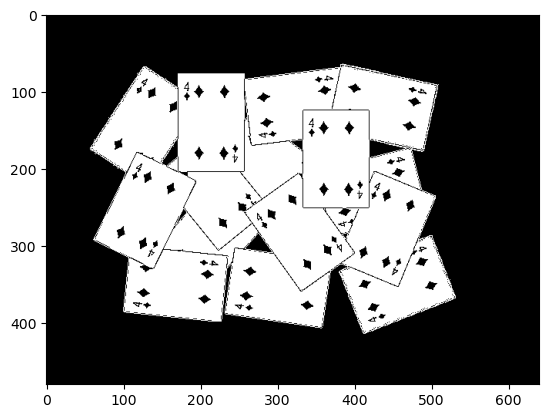

In [69]:
# Create binary image from source image
bw = cv2.cvtColor(imgResult, cv2.COLOR_BGR2GRAY)
_, bw = cv2.threshold(bw, 40, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
plt.imshow(bw, cmap="Greys_r");

### Distance transform

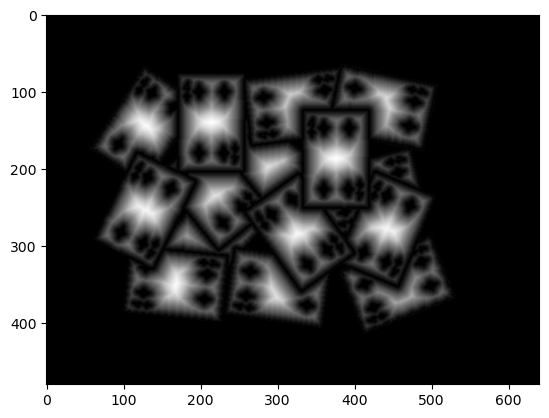

In [70]:
# Perform the distance transform algorithm
dist = cv2.distanceTransform(bw, cv2.DIST_L2, 3)
# Normalize the distance image for range = {0.0, 1.0}
# so we can visualize and threshold it
cv2.normalize(dist, dist, 0, 1.0, cv2.NORM_MINMAX)
plt.imshow(dist, cmap="Greys_r");

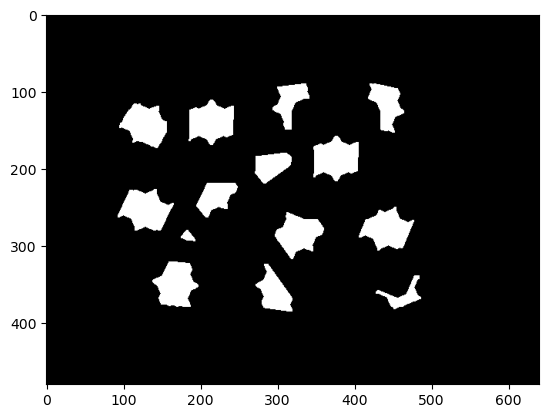

In [71]:
# Threshold to obtain the peaks
# This will be the markers for the foreground objects
_, dist = cv2.threshold(dist, 0.4, 1.0, cv2.THRESH_BINARY)
# Dilate a bit the dist image
kernel1 = np.ones((3,3), dtype=np.uint8)
dist = cv2.dilate(dist, kernel1)
plt.imshow(dist, cmap="Greys_r");

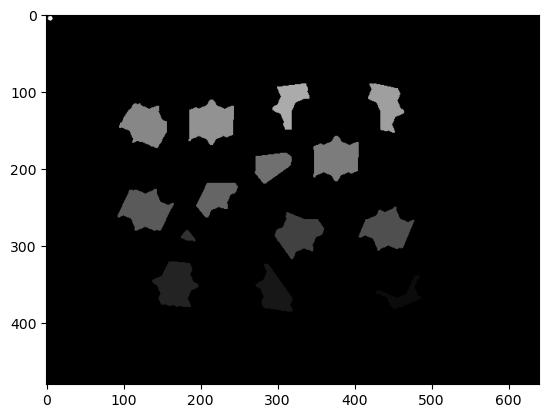

In [72]:
# Create the CV_8U version of the distance image
# It is needed for findContours()
dist_8u = dist.astype('uint8')
# Find total markers
contours, _ = cv2.findContours(dist_8u, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Create the marker image for the watershed algorithm
markers = np.zeros(dist.shape, dtype=np.int32)
# Draw the foreground markers
for i in range(len(contours)):
    cv2.drawContours(
        markers,   # image
        contours,  # contours list
        i,         # contour index to draw
        (i+1),     # color (fill value)
        -1,        # thickness (if negative - fill the contour)
    )
# Draw the background marker
cv2.circle(
    markers,        # image
    (5,5),          # center
    3,              # radius
    (255,255,255),  # color
    -1,             # thickness (if negative - fill)
)

markers_8u = (markers * 10).astype('uint8')
plt.imshow(markers_8u, cmap="Greys_r");

### Алгоритм Watershed

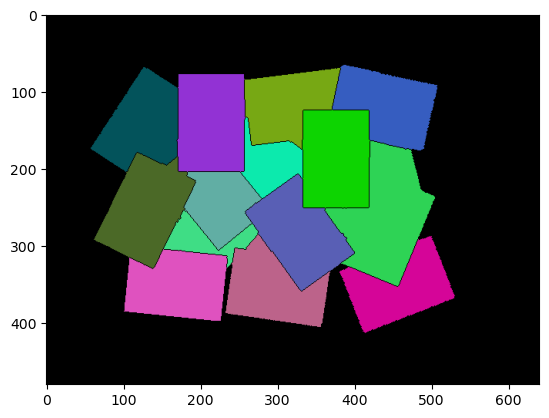

In [73]:
# Perform the watershed algorithm
cv2.watershed(imgResult, markers)

mark = markers.astype('uint8')
mark = cv2.bitwise_not(mark)
# uncomment this if you want to see how the mark
# image looks like at that point
# plt.imshow(mark)
# Generate random colors
colors = []
for contour in contours:
    colors.append((rng.randint(0,256), rng.randint(0,256), rng.randint(0,256)))
# Create the result image
dst = np.zeros((markers.shape[0], markers.shape[1], 3), dtype=np.uint8)
# Fill labeled objects with random colors
for i in range(markers.shape[0]):
    for j in range(markers.shape[1]):
        index = markers[i,j]
        if index > 0 and index <= len(contours):
            dst[i,j,:] = colors[index-1]

# Visualize the final image
plt.imshow(dst);

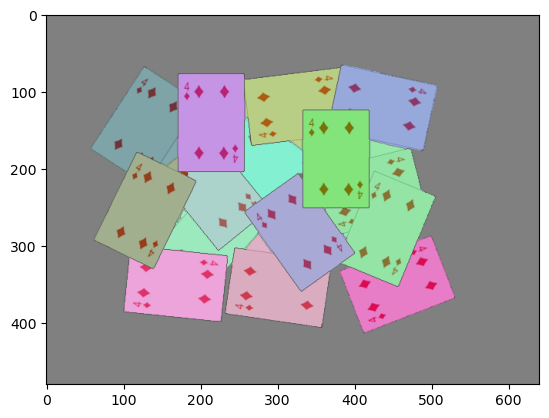

In [74]:
blended = cv2.addWeighted(img_src, 0.5, dst, 0.5, 0.0)
plt.imshow(blended);

# Домашнее задание: подсчет количества пальцев

**Это оцениваемое ДЗ**

Вам предлагается реализовать алгоритм, подсчитывающий количество пальцев.

Один из возможных вариантов решения:
- Получить бинаризованное изображение и найти контур руки;
- Построить выпуклый контур функцией `cv2.convexHull` - https://docs.opencv.org/3.4/d7/d1d/tutorial_hull.html
- Найти дефекты выпуклости контура функцией [`cv2.convexityDefects`](https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#gada4437098113fd8683c932e0567f47ba)
- После некоторой фильтрации дефектов, их число будет напрямую коррелировать с числом пальцев.

**Требования:**
1. Продемонстрируйте работоспособность алгоритма на любом числе пальцев (от 0 до 5).
2. Используйте фото своей руки для демонстрации (предложенное фото лишь для отладки).

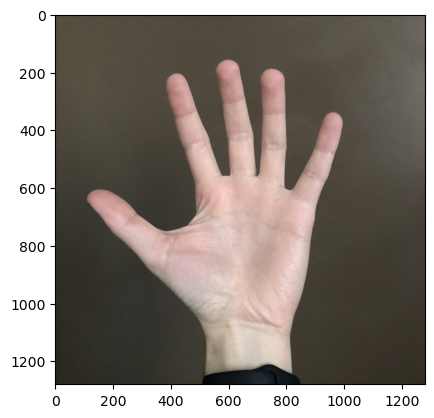

In [75]:
img = cv2.cvtColor(cv2.imread("data/hand.jpg"), cv2.COLOR_BGR2RGB)
plt.imshow(img);

In [78]:
import math

def count_fingers(image_path):
    img = cv2.imread(image_path)

    h, w = img.shape[:2]
    img = img[50 : h-50, 100 : w-100]

    img_draw = img.copy()
    
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower_skin = np.array([0, 50, 86])
    upper_skin = np.array([20, 255, 255])
    mask = cv2.inRange(hsv, lower_skin, upper_skin)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel) 
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    max_area = 0
    cnt = None
    for i in range(len(contours)):
        area = cv2.contourArea(contours[i])
        if area > max_area:
            max_area = area
            cnt = contours[i]

    hull_indices = cv2.convexHull(cnt, returnPoints=False)
    hull_points = cv2.convexHull(cnt, returnPoints=True) 
    
    cv2.drawContours(img_draw, [cnt], -1, (0, 255, 0), 2)
    cv2.drawContours(img_draw, [hull_points], -1, (255, 0, 0), 2)

    defects = cv2.convexityDefects(cnt, hull_indices)
    
    count_defects = 0
    
    if defects is not None:
        for i in range(defects.shape[0]):
            s, e, f, d = defects[i, 0]
            
            x1, y1 = cnt[s][0]
            x2, y2 = cnt[e][0]
            x0, y0 = cnt[f][0]
            
            a = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
            b = math.sqrt((x0 - x1)**2 + (y0 - y1)**2)
            c = math.sqrt((x2 - x0)**2 + (y2 - y0)**2)
            
            try:
                angle = math.acos((b**2 + c**2 - a**2) / (2 * b * c)) * 180 / math.pi
                if angle <= 90 and d > 10000:
                    count_defects += 1
                    cv2.circle(img_draw, (x0, y0), 8, (0, 0, 255), -1)
            except ValueError:
                pass
            except ZeroDivisionError:
                pass
                
    fingers = 0
    
    if count_defects > 0:
        fingers = count_defects + 1
    else:
        area = cv2.contourArea(cnt)
        hull_area = cv2.contourArea(hull_points)
        
        ratio = 0
        if hull_area != 0:
            ratio = area / hull_area
            
        if ratio > 0.84:
            fingers = 0
        else:
            fingers = 1

    cv2.putText(img_draw, f"Fingers: {fingers}", (50, 50), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 0, 0), 3)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title('Оригинал')
    plt.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title('Маска руки')
    plt.imshow(mask, cmap='gray')
    plt.axis('off')
    plt.show()
    
    return fingers

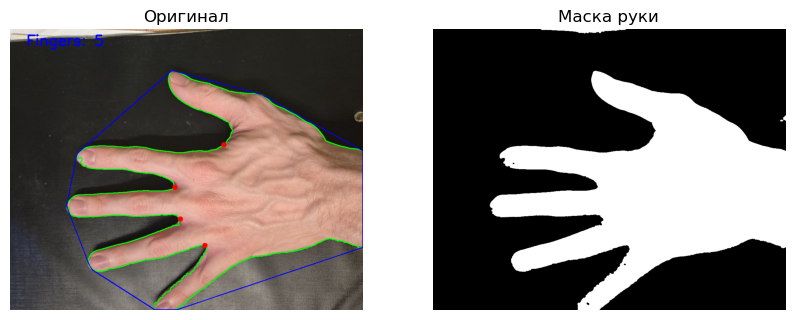

На фото hand_1.jpg распознано пальцев: 5


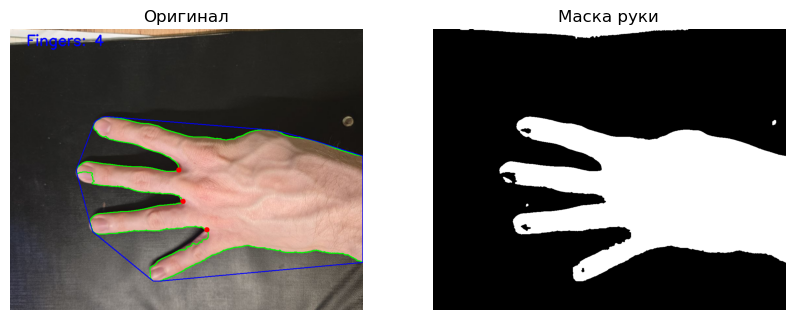

На фото hand_2.jpg распознано пальцев: 4


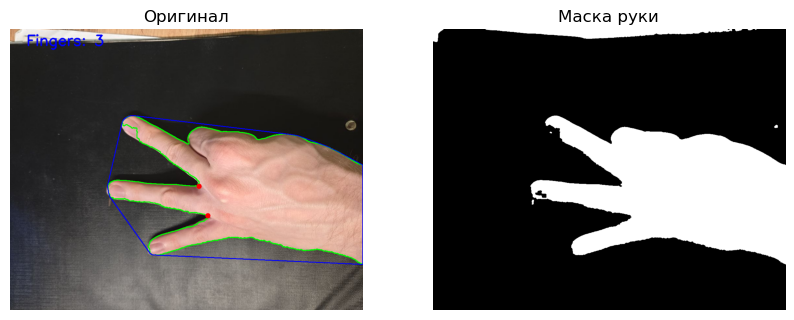

На фото hand_3.jpg распознано пальцев: 3


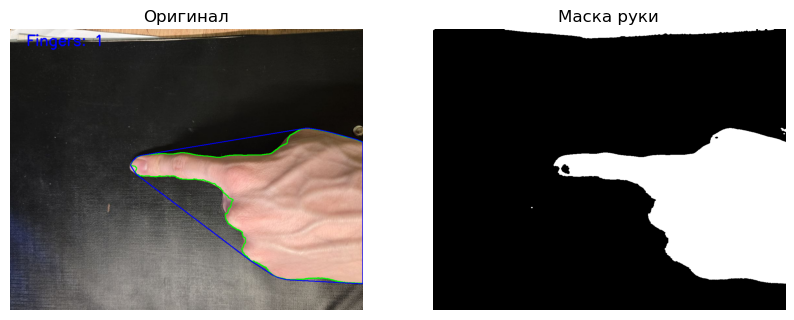

На фото hand_4.jpg распознано пальцев: 1


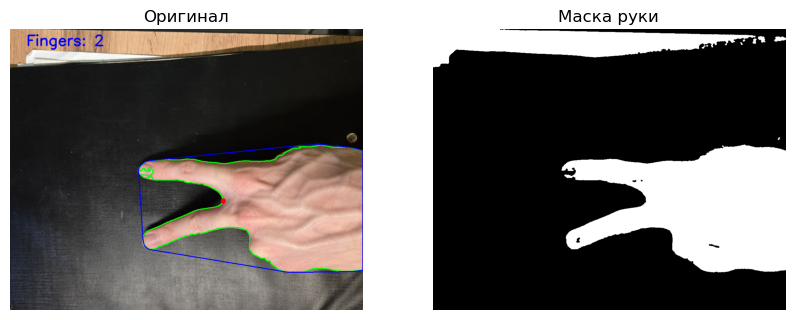

На фото hand_5.jpg распознано пальцев: 2


In [77]:
# Мои фото
for i in range(1, 6):
    count = count_fingers(f"/home/homa/education/cv_course_2026/seminars/seminar_06/data/hand_{i}.jpg")
    print(f"На фото hand_{i}.jpg распознано пальцев: {count}")